<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 107 · Core Classification & Regression Algorithms</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Core Classification &amp; Regression Algorithms</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The five workhorses of tabular ML on a heart-disease table: KNN, decision trees, naive Bayes, SVM, and logistic regression, their very different decision boundaries, a readable tree, a cross-validated head-to-head, and the regression twin of each, library-first and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Core Classification &amp; Regression Algorithms
Five workhorses account for most tabular machine learning: **K-nearest neighbors, decision trees, naive Bayes, support vector machines, and logistic regression**. This notebook trains all five on a heart-disease table, draws the very different **decision boundary** each one carves, reads a tree's rules, races them head to head, and shows every classifier has a **regression twin**. Library-first with `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
pd.set_option('display.max_columns', 30)

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 &#183; THE LINEUP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One dataset, five algorithms</div>
<div style="color:#4a5578;margin-top:6px">Load the patients and set up the contenders.</div>
</div>

In [3]:
try: df = pd.read_excel('../../data/core-classification-and-regression-algorithms--patients.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'core-classification-and-regression-algorithms--patients.xlsx', sheet_name='Data')
feat = ['age','resting_bp','cholesterol','max_hr','glucose','bmi']
X, y = df[feat], df['heart_disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
print(f'{len(df)} patients, disease rate {y.mean():.0%}; {len(X_train)} train / {len(X_test)} test')
df.head(4)

700 patients, disease rate 35%; 525 train / 175 test


,patient_id,age,resting_bp,cholesterol,max_hr,glucose,bmi,heart_disease
0,P4000,57,157,263,171,98,34.1,1
1,P4001,37,127,221,192,103,23.3,0
2,P4002,54,126,200,145,111,28.4,0
3,P4003,70,130,312,164,130,32.7,1


**The five contenders.** **KNN** classifies by the majority vote of the nearest patients. A **decision tree** asks a sequence of yes/no questions. **Naive Bayes** multiplies simple per-feature probabilities (assuming features are independent). An **SVM** finds the widest-margin boundary, curved if it uses a kernel. **Logistic regression** fits a linear boundary and returns calibrated probabilities. KNN, SVM, and logistic regression need **standardized** features (they measure distance or weighted sums), so we wrap those in a pipeline.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; HOW EACH DRAWS A BOUNDARY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The same data, five very different shapes</div>
<div style="color:#4a5578;margin-top:6px">Trained on two features so we can see the decision surface.</div>
</div>

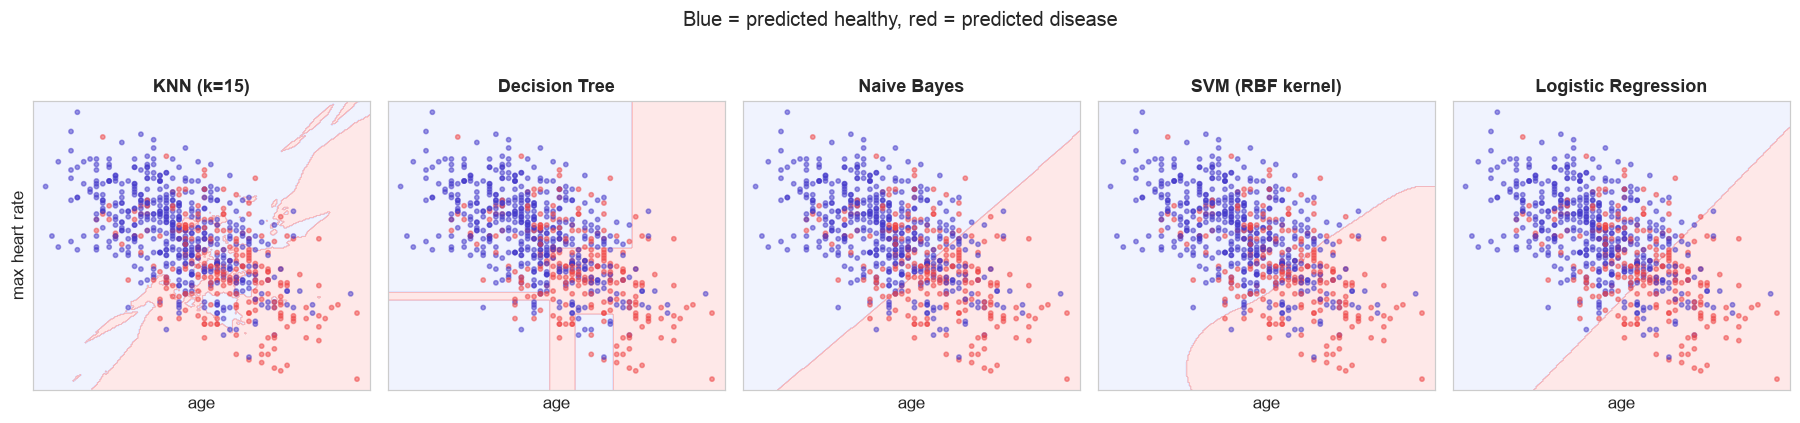

In [4]:
X2 = df[['age','max_hr']].values; yv = df['heart_disease'].values
models2 = {'KNN (k=15)': make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
           'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=0),
           'Naive Bayes': GaussianNB(),
           'SVM (RBF kernel)': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1)),
           'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression())}
xx, yy = np.meshgrid(np.linspace(X2[:,0].min()-2, X2[:,0].max()+2, 250), np.linspace(X2[:,1].min()-4, X2[:,1].max()+4, 250))
fig, axes = plt.subplots(1, 5, figsize=(16.5,3.7))
for ax,(name,m) in zip(axes, models2.items()):
    m.fit(X2, yv)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap([LIGHT, '#fca5a5']))
    ax.scatter(X2[:,0], X2[:,1], c=yv, cmap=ListedColormap([EM, RED]), s=8, alpha=0.5)
    ax.set(title=name, xlabel='age', xticks=[], yticks=[])
axes[0].set_ylabel('max heart rate')
plt.suptitle('Blue = predicted healthy, red = predicted disease', y=1.03); plt.tight_layout(); plt.show()

**Reading the boundaries.** Every model separates the same points, but the shape of the boundary reveals how it thinks. **KNN** is wiggly and local, it follows clusters of neighbors. The **decision tree** is made of axis-aligned rectangles, one per yes/no split. **Naive Bayes** is a smooth quadratic curve. The **RBF SVM** bends flexibly to the data. **Logistic regression** is a single straight line. Simpler boundaries (a line) generalize more but can underfit; wigglier ones (KNN) fit local detail but risk overfitting, exactly the bias-variance trade-off.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; A DECISION TREE IS READABLE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Rules a doctor could follow</div>
<div style="color:#4a5578;margin-top:6px">Trees trade a little accuracy for full transparency.</div>
</div>

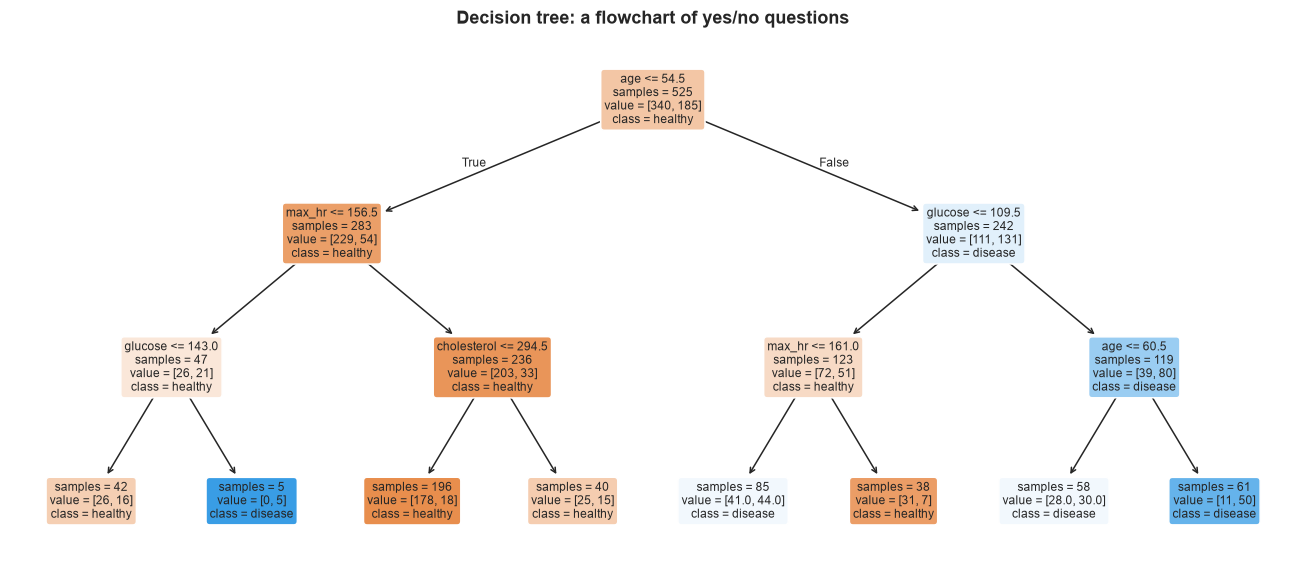

feature importances:
age            0.555
max_hr         0.196
glucose        0.170
cholesterol    0.079
resting_bp     0.000
bmi            0.000


In [5]:
tree = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(12,5.4))
plot_tree(tree, feature_names=feat, class_names=['healthy','disease'], filled=True, rounded=True, fontsize=8, ax=ax, impurity=False)
plt.title('Decision tree: a flowchart of yes/no questions'); plt.tight_layout(); plt.show()
imp = pd.Series(tree.feature_importances_, index=feat).sort_values(ascending=False)
print('feature importances:'); print(imp.round(3).to_string())

**Why trees are special.** You can literally read the model: start at the top and follow the yes/no questions (is age above a threshold? is max heart rate below one?) to a prediction. That **interpretability** is why trees are prized in medicine and finance, and the **feature importances** rank which questions mattered most, here age and max heart rate dominate. The cost is that a single tree is a step-function and slightly less accurate than smoother models, which the next chapter fixes with ensembles.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 4 &#183; HEAD TO HEAD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Which one wins on the full data?</div>
<div style="color:#4a5578;margin-top:6px">Cross-validated accuracy on all six features.</div>
</div>

Decision Tree          0.683
KNN                    0.750
Naive Bayes            0.759
SVM (RBF)              0.766
Logistic Regression    0.773


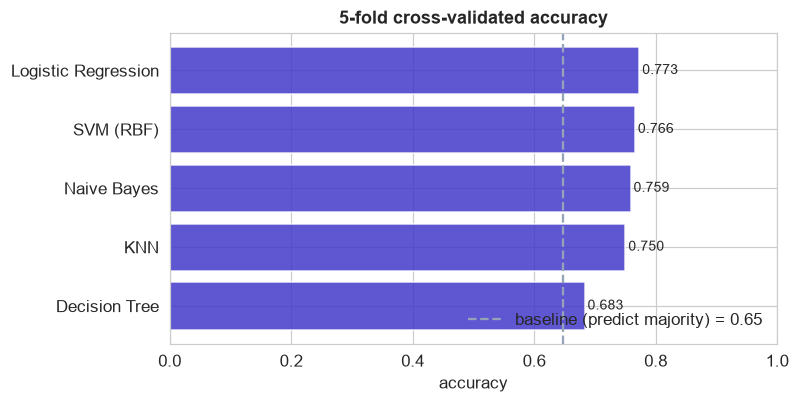

In [6]:
models = {'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
          'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=0),
          'Naive Bayes': GaussianNB(),
          'SVM (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf')),
          'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))}
cv = {name: cross_val_score(m, X, y, cv=5).mean() for name,m in models.items()}
cv = pd.Series(cv).sort_values()
print(cv.round(3).to_string())
fig, ax = plt.subplots(figsize=(7.4,3.8))
ax.barh(cv.index, cv.values, color=EM, alpha=0.85)
ax.axvline(1-y.mean(), color=GREY, ls='--', label=f'baseline (predict majority) = {1-y.mean():.2f}')
for i,v in enumerate(cv.values): ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set(title='5-fold cross-validated accuracy', xlabel='accuracy', xlim=(0,1)); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**What the race shows.** On this dataset the linear models (logistic regression and the SVM) lead, naive Bayes and KNN follow close behind, and the single decision tree trails, all above the majority-class baseline. There is **no universally best algorithm** (the 'no free lunch' rule): the winner depends on the data's shape, the sample size, and how much interpretability or speed you need. The right habit is to **cross-validate a handful of models** and let the numbers, plus your constraints, decide.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; THE REGRESSION TWINS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Every classifier has a regressor</div>
<div style="color:#4a5578;margin-top:6px">Swap the category for a number and the same ideas predict quantities.</div>
</div>

KNN regressor        test R2 = 0.274
Tree regressor       test R2 = 0.273
Linear regression    test R2 = 0.356


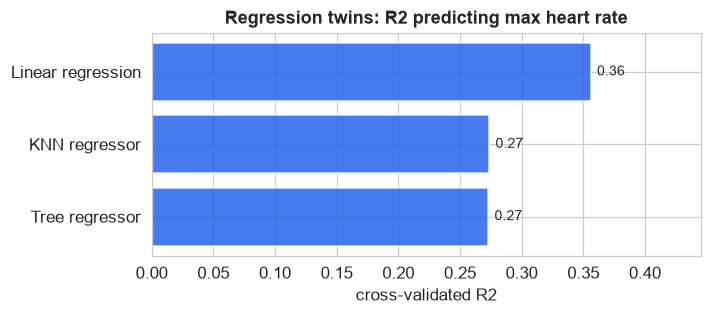

In [7]:
Xr = df[['age','resting_bp','cholesterol','glucose','bmi']]; yr = df['max_hr']   # predict max heart rate
regs = {'KNN regressor': make_pipeline(StandardScaler(), KNeighborsRegressor(15)),
        'Tree regressor': DecisionTreeRegressor(max_depth=4, random_state=0),
        'Linear regression': LinearRegression()}
r2s = {name: cross_val_score(r, Xr, yr, cv=5, scoring='r2').mean() for name,r in regs.items()}
for name,v in r2s.items(): print(f'{name:20s} test R2 = {v:.3f}')
s = pd.Series(r2s).sort_values()
fig, ax = plt.subplots(figsize=(6.6,3.0))
ax.barh(s.index, s.values, color=BLUE, alpha=0.85)
for i,v in enumerate(s.values): ax.text(v+0.005, i, f'{v:.2f}', va='center', fontsize=9)
ax.set(title='Regression twins: R2 predicting max heart rate', xlabel='cross-validated R2', xlim=(0, max(s.values)*1.25)); plt.tight_layout(); plt.show()

**The symmetry.** KNN, decision trees, and linear models each come in **two flavors**: a *classifier* that predicts a category and a *regressor* that predicts a number, using the identical underlying idea (nearest neighbors average their targets; a tree averages the values in each leaf; linear regression fits a line). scikit-learn mirrors this in its names, `KNeighborsClassifier` and `KNeighborsRegressor`, so once you know the classifier you already know its regression twin. Here they predict a patient's maximum heart rate from age and the other measurements.

## When to reach for each

- **Logistic regression**: the baseline, fast, interpretable (odds ratios), calibrated probabilities, linear boundary. Start here.
- **K-nearest neighbors**: simple and flexible; needs scaling; slow to predict on big data; great when the boundary is irregular.
- **Decision tree**: fully interpretable rules, no scaling needed, handles mixed features; a single tree overfits (ensembles fix that).
- **Naive Bayes**: extremely fast, strong with high-dimensional text; the independence assumption is crude but often works.
- **SVM**: powerful boundaries via kernels, strong in high dimensions; needs scaling and tuning; less interpretable.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>